In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.patches as patches
import img2pdf

current_dir = Path.cwd()

# Parent directory
parent_dir = current_dir.parent

# Directories containing your modules
vis_dir = parent_dir / "vis"
connected_graphs_dir = parent_dir / "vis_connect"
long_dir = parent_dir / "long_peptide"

# Put them at the front of sys.path
sys.path.insert(0, str(vis_dir))
sys.path.insert(0, str(connected_graphs_dir))
sys.path.insert(0, str(long_dir))

import data_parse
import util
import peptide
import pandas as pd
import numpy as np
import connected_graph
from bisect import bisect_left

In [ ]:

path = '/Users/kevinmbp/Desktop/2D_spec_dict/data/virtual_MSMS/VEADIAGHGQEVLIR-mz536-z3_Intensity_Sum'

# 1. Read the spectral file with the custom split to keep annotations intact
with open(path, 'r') as f:
    data = [line.strip().split(None, 3) for line in f if line.strip()]

# 2. Create the spectral DataFrame
df_msms = pd.DataFrame(data, columns=["intensity", "mz", "error", "annotation"])

# 3. Convert columns to numeric types
df_msms["mz"] = pd.to_numeric(df_msms["mz"], errors="coerce")
df_msms["intensity"] = pd.to_numeric(df_msms["intensity"], errors="coerce")
df_msms["error"] = pd.to_numeric(df_msms["error"], errors="coerce")

# 4. Clean up NaNs and sort by m/z (required for merge_asof)
df_msms = df_msms.dropna(subset=["mz", "intensity"]).sort_values("mz").reset_index(drop=True)

# --- Process MMS File ---
mss_input_file = "/Users/kevinmbp/Desktop/2D_spec_dict/data/short_peptide/VEA3+.txt"
mms_df = pd.read_csv(
    mss_input_file,
    sep=r"\s+",
    skiprows=1,
    header=None,
    engine="python"
)

mms_df.columns = ["m/z A", "m/z B", "Covariance", "Partial Cov.", "Score", "Ranking"]
mms_df["m/z A"] = pd.to_numeric(mms_df["m/z A"], errors="coerce")
mms_df["m/z B"] = pd.to_numeric(mms_df["m/z B"], errors="coerce")
tolerance = 0.001

# -------- Match for m/z A --------
a_df = mms_df[["m/z A"]].copy().sort_values("m/z A").reset_index()
a_matched = pd.merge_asof(
    a_df,
    df_msms,
    left_on="m/z A",
    right_on="mz",
    direction="nearest",
    tolerance=tolerance
)
# Rename intensity, annotation, and error for A
a_matched = a_matched.rename(columns={
    "intensity": "intensity A", 
    "annotation": "annotation A",
    "error": "error A"
})
a_matched = a_matched.set_index("index")

# -------- Match for m/z B --------
b_df = mms_df[["m/z B"]].copy().sort_values("m/z B").reset_index()
b_matched = pd.merge_asof(
    b_df,
    df_msms,
    left_on="m/z B",
    right_on="mz",
    direction="nearest",
    tolerance=tolerance
)
# Rename intensity, annotation, and error for B
b_matched = b_matched.rename(columns={
    "intensity": "intensity B", 
    "annotation": "annotation B",
    "error": "error B"
})
b_matched = b_matched.set_index("index")

# -------- Final Join --------
# Add all matched columns back to the original MMS dataframe
mms_df["intensity A"] = a_matched["intensity A"]
mms_df["annotation A"] = a_matched["annotation A"]
mms_df["error A"] = a_matched["error A"]

mms_df["intensity B"] = b_matched["intensity B"]
mms_df["annotation B"] = b_matched["annotation B"]
mms_df["error B"] = b_matched["error B"]

mms_df.head()

,m/z A,m/z B,Covariance,Partial Cov.,Score,Ranking,intensity A,annotation A,error A,intensity B,annotation B,error B
0,156.102426,156.102426,25073159.00,2.503813e+07,1604.311900,-1,968.253174,No Match,-1000.0,968.253174,No Match,-1000.000000
1,156.102426,175.119605,1766662.60,1.577744e+06,183.251870,282,968.253174,No Match,-1000.0,8633.249023,y1 (+1),-0.000653
2,156.102426,183.113388,1159704.90,9.680421e+05,139.187240,740,968.253174,No Match,-1000.0,6728.792969,b2-H2O-CO (+1) / b2-HCOOH (+1) / internal 4:5-...,-0.000584
3,156.102426,187.072039,116453.27,9.340415e+04,28.558445,4715,968.253174,No Match,-1000.0,973.557800,internal 3:4 (+1),-0.000706
4,156.102426,195.088350,-310522.16,-3.434978e+05,-186.746850,13511,968.253174,No Match,-1000.0,1063.230103,internal 7:8 (+1) / internal 8:9 (+1),-0.000698


In [12]:
mms_df = mms_df[['m/z A', 'm/z B', 'Ranking', 'annotation A', 'annotation B']]
mms_df = mms_df[mms_df['Ranking'] != -1]
mms_df = mms_df[mms_df['Ranking'] <= 100]

In [13]:
def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    num_random_lines=4,
    xlim=None,
    ylim=None,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    random_seed=42
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing mz_A, mz_B, and ranking columns.

    mz_a_col : str
        Column name for mz_A values.

    mz_b_col : str
        Column name for mz_B values.

    ranking_col : str
        Column name for FFC ranking.

    lines : list of dict, optional
        List of line parameters. Each line should be a dictionary like:
            {"slope": -1, "intercept": 1400, "color": "blue", "label": "line 1"}

        The line is drawn as:
            y = slope * x + intercept

        If None, random lines will be generated.

    num_random_lines : int
        Number of random lines to draw if lines is None.

    xlim : tuple, optional
        x-axis limits, for example (150, 1250).

    ylim : tuple, optional
        y-axis limits, for example (150, 1250).

    figsize : tuple
        Figure size.

    point_size : int
        Scatter point size.

    line_alpha : float
        Transparency of the lines.

    random_seed : int
        Random seed for generating random lines.
    """

    # Make a copy to avoid modifying the original dataframe
    data = df.copy()

    # Convert columns to numeric values
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Remove rows with missing values
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    # Determine plot ranges
    if xlim is None:
        x_min = data[mz_a_col].min() - 50
        x_max = data[mz_a_col].max() + 50
        xlim = (x_min, x_max)

    if ylim is None:
        y_min = data[mz_b_col].min() - 50
        y_max = data[mz_b_col].max() + 50
        ylim = (y_min, y_max)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Scatter plot
    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75
    )

    # Color bar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # Generate random lines if no line parameters are provided
    if lines is None:
        np.random.seed(random_seed)
        lines = []

        for i in range(num_random_lines):
            slope = np.random.uniform(-2.0, -0.3)
            intercept = np.random.uniform(800, 1700)
            color = np.random.choice(["blue", "green", "purple", "orange", "red"])

            lines.append({
                "slope": slope,
                "intercept": intercept,
                "color": color,
                "label": f"random line {i + 1}"
            })

    # Draw lines
    x_values = np.linspace(xlim[0], xlim[1], 500)

    for line in lines:
        slope = line.get("slope")
        intercept = line.get("intercept")
        color = line.get("color", "black")
        label = line.get("label", None)

        y_values = slope * x_values + intercept

        ax.plot(
            x_values,
            y_values,
            color=color,
            alpha=line_alpha,
            linewidth=2,
            label=label
        )

    # Labels and formatting
    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="both", labelsize=12)

    # Optional legend, useful when you start labeling exact lines
    if any(line.get("label") is not None for line in lines):
        ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

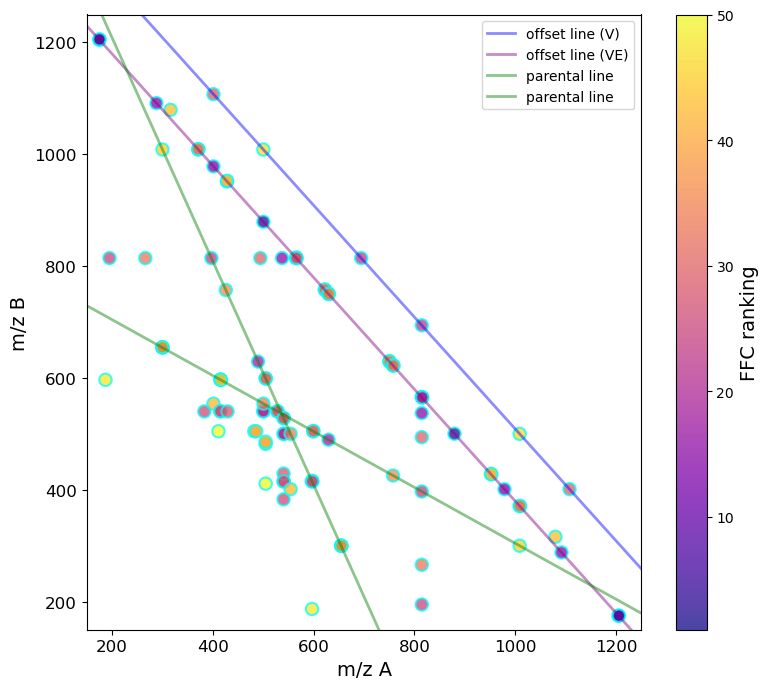

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [19]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "offset line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "offset line (VE)"},
    {"slope": -0.5, "intercept": 1608.869/2, "color": "green", "label": "parental line"},
    {"slope": -2, "intercept": 1608.869, "color": "green", "label": "parental line"}
]

plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    xlim=(150, 1250),
    ylim=(150, 1250)
)

In [22]:
PEP_SEQ = "VEADIAGHGQEVLIR"
CHARGE = 3
pep = peptide.Pep(f"[{PEP_SEQ}+{CHARGE}H]{CHARGE}+", end_h20=True)

In [46]:
b_ions = {f'b{i}':pep.ion_mass(f'b{i}') for i in range(1, len(PEP_SEQ))}
y_ions = {f'y{i}':pep.ion_mass(f'y{i}') for i in range(1, len(PEP_SEQ))}

In [47]:
def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    num_random_lines=4,
    xlim=None,
    ylim=None,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    grid_alpha=0.12,
    grid_linewidth=0.8,
    random_seed=42
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing mz_A, mz_B, and ranking columns.

    b_ions : dict, optional
        Dictionary of b-ion values, for example:
            {"b1": 175.119, "b2": 304.162, "b3": 419.189}

        These values are drawn as vertical gray grid lines.

    y_ions : dict, optional
        Dictionary of y-ion values, for example:
            {"y1": 175.119, "y2": 288.203, "y3": 417.246}

        These values are drawn as horizontal gray grid lines.

    lines : list of dict, optional
        Main line parameters. Each line should be:
            {"slope": -1, "intercept": 1400, "color": "blue", "label": "parental line"}

        The line is drawn as:
            y = slope * x + intercept
    """

    data = df.copy()

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if xlim is None:
        x_min = data[mz_a_col].min() - 50
        x_max = data[mz_a_col].max() + 50
        xlim = (x_min, x_max)

    if ylim is None:
        y_min = data[mz_b_col].min() - 50
        y_max = data[mz_b_col].max() + 50
        ylim = (y_min, y_max)

    fig, ax = plt.subplots(figsize=figsize)

    # Add barely visible b/y ion grid first, so it stays behind the points
    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

    # Scatter plot
    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75,
        zorder=3
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # Generate random lines if no exact lines are provided
    if lines is None:
        np.random.seed(random_seed)
        lines = []

        for i in range(num_random_lines):
            slope = np.random.uniform(-2.0, -0.3)
            intercept = np.random.uniform(800, 1700)
            color = np.random.choice(["blue", "green", "purple", "orange", "red"])

            lines.append({
                "slope": slope,
                "intercept": intercept,
                "color": color,
                "label": f"random line {i + 1}"
            })

    # Draw main diagonal/charge lines
    x_values = np.linspace(xlim[0], xlim[1], 500)

    for line in lines:
        slope = line.get("slope")
        intercept = line.get("intercept")
        color = line.get("color", "black")
        label = line.get("label", None)

        y_values = slope * x_values + intercept

        ax.plot(
            x_values,
            y_values,
            color=color,
            alpha=line_alpha,
            linewidth=2,
            label=label,
            zorder=2
        )

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="both", labelsize=12)

    if any(line.get("label") is not None for line in lines):
        ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

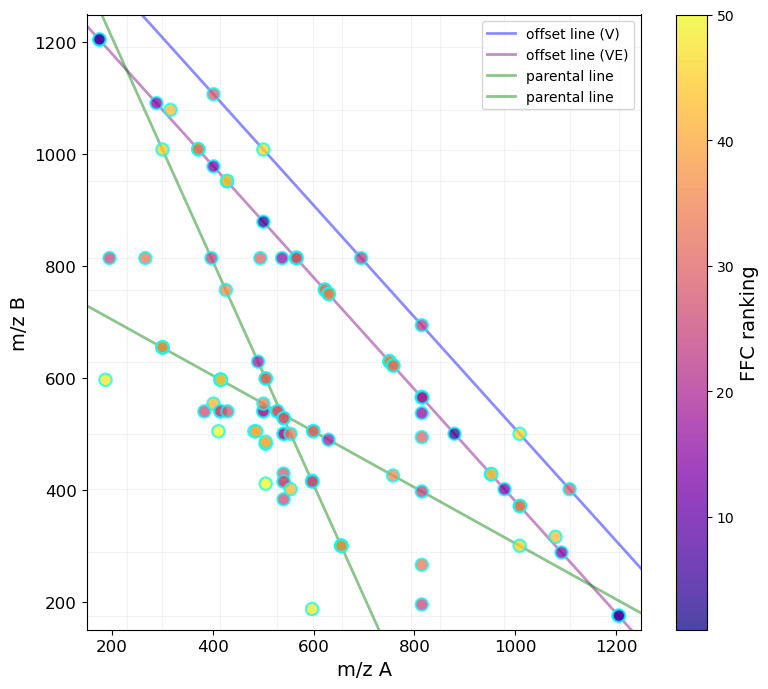

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [48]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "offset line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "offset line (VE)"},
    {"slope": -0.5, "intercept": 1608.869/2, "color": "green", "label": "parental line"},
    {"slope": -2, "intercept": 1608.869, "color": "green", "label": "parental line"}
]

plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(150, 1250),
    ylim=(150, 1250),
    grid_alpha=0.10,
    lines=exact_lines
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    num_random_lines=4,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.45,
    grid_label_fontsize=7,
    show_grid_labels=True,
    random_seed=42
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing mz_A, mz_B, and ranking columns.

    mz_a_col : str
        Column name for mz_A values.

    mz_b_col : str
        Column name for mz_B values.

    ranking_col : str
        Column name for FFC ranking.

    lines : list of dict, optional
        Main line parameters. Each line should be:
            {
                "slope": -1,
                "intercept": 1400,
                "color": "blue",
                "label": "parental line"
            }

        The line is drawn as:
            y = slope * x + intercept

    b_ions : dict, optional
        Dictionary of b-ion values, for example:
            {
                "b1": 175.119,
                "b2": 304.162,
                "b3": 419.189
            }

        These values are drawn as vertical gray lines.
        Their labels are placed near the bottom of the plot.

    y_ions : dict, optional
        Dictionary of y-ion values, for example:
            {
                "y1": 175.119,
                "y2": 288.203,
                "y3": 417.246
            }

        These values are drawn as horizontal gray lines.
        Their labels are placed near the left side of the plot.

    start_from_zero : bool
        If True, automatically starts both axes from 0 when xlim/ylim are not provided.

    num_random_lines : int
        Number of random lines to draw if lines is None.

    xlim : tuple, optional
        x-axis limits, for example (0, 1250).

    ylim : tuple, optional
        y-axis limits, for example (0, 1250).

    figsize : tuple
        Figure size.

    point_size : int
        Scatter point size.

    line_alpha : float
        Transparency of the main diagonal/charge lines.

    grid_alpha : float
        Transparency of the b/y ion grid lines.

    grid_linewidth : float
        Width of the b/y ion grid lines.

    grid_label_alpha : float
        Transparency of the b/y ion labels.

    grid_label_fontsize : int
        Font size of the b/y ion labels.

    show_grid_labels : bool
        Whether to show b/y ion labels.

    random_seed : int
        Random seed for generating random lines.
    """

    data = df.copy()

    # Convert columns to numeric values
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (
                0,
                data[mz_a_col].max() + 50
            )
        else:
            xlim = (
                data[mz_a_col].min() - 50,
                data[mz_a_col].max() + 50
            )

    if ylim is None:
        if start_from_zero:
            ylim = (
                0,
                data[mz_b_col].max() + 50
            )
        else:
            ylim = (
                data[mz_b_col].min() - 50,
                data[mz_b_col].max() + 50
            )

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Add faint b/y ion grid
    # ------------------------------------------------------------

    # b-ion labels near the bottom of the plot
    b_label_y = ylim[0] + 0.02 * (ylim[1] - ylim[0])

    # y-ion labels near the left side of the plot
    y_label_x = xlim[0] + 0.01 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75,
        zorder=3
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Generate random lines if no exact lines are provided
    # ------------------------------------------------------------

    if lines is None:
        np.random.seed(random_seed)
        lines = []

        for i in range(num_random_lines):
            slope = np.random.uniform(-2.0, -0.3)
            intercept = np.random.uniform(800, 1700)
            color = np.random.choice(["blue", "green", "purple", "orange", "red"])

            lines.append({
                "slope": slope,
                "intercept": intercept,
                "color": color,
                "label": f"random line {i + 1}"
            })

    # ------------------------------------------------------------
    # Draw main diagonal/charge lines
    # ------------------------------------------------------------

    x_values = np.linspace(xlim[0], xlim[1], 500)

    for line in lines:
        slope = line.get("slope")
        intercept = line.get("intercept")
        color = line.get("color", "black")
        label = line.get("label", None)

        y_values = slope * x_values + intercept

        ax.plot(
            x_values,
            y_values,
            color=color,
            alpha=line_alpha,
            linewidth=2,
            label=label,
            zorder=2
        )

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="both", labelsize=12)

    if lines is not None and any(line.get("label") is not None for line in lines):
        ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

In [112]:
combined_ions = {**y_ions, **b_ions}

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_ffc_map_by_grid_type(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    num_random_lines=4,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    make_plot_square=False,
    figsize=(8, 7),
    point_size=80,
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=1.5,
    cmap="plasma",
    line_alpha=0.45,
    ion_grid_alpha=0.18,
    ion_grid_linewidth=0.8,
    b_grid_color="tab:blue",
    y_grid_color="tab:green",
    grid_label_alpha=0.65,
    grid_label_fontsize=7,
    show_grid_labels=True,
    show_ion_grid_legend=True,
    random_seed=42
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Compared with the previous version, this version shows BOTH b-ion
    and y-ion values on BOTH axes.

    b_ions:
        Drawn as vertical lines on x-axis and horizontal lines on y-axis
        using b_grid_color.

    y_ions:
        Drawn as vertical lines on x-axis and horizontal lines on y-axis
        using y_grid_color.

    lines:
        Optional main diagonal/charge lines, each in slope-intercept form:
            y = slope * x + intercept
    """

    data = df.copy()

    # Convert columns to numeric values
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 50)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 50)

    if make_plot_square:
        max_limit = max(xlim[1], ylim[1])
        xlim = (xlim[0], max_limit)
        ylim = (ylim[0], max_limit)

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Add b/y ion grid on BOTH axes
    # ------------------------------------------------------------

    x_label_bottom_y = ylim[0] + 0.02 * (ylim[1] - ylim[0])
    x_label_top_y = ylim[1] - 0.02 * (ylim[1] - ylim[0])

    y_label_left_x = xlim[0] + 0.01 * (xlim[1] - xlim[0])
    y_label_right_x = xlim[1] - 0.01 * (xlim[1] - xlim[0])

    # b-ion grid: vertical + horizontal
    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            # b-ion vertical line on x-axis
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color=b_grid_color,
                    alpha=ion_grid_alpha,
                    linewidth=ion_grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        x_label_bottom_y,
                        ion_name,
                        color=b_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                    )

            # b-ion horizontal line on y-axis
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color=b_grid_color,
                    alpha=ion_grid_alpha,
                    linewidth=ion_grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_left_x,
                        mz_value,
                        ion_name,
                        color=b_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                    )

    # y-ion grid: vertical + horizontal
    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            # y-ion vertical line on x-axis
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color=y_grid_color,
                    alpha=ion_grid_alpha,
                    linewidth=ion_grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        x_label_top_y,
                        ion_name,
                        color=y_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="top",
                        zorder=1,
                    )

            # y-ion horizontal line on y-axis
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color=y_grid_color,
                    alpha=ion_grid_alpha,
                    linewidth=ion_grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_right_x,
                        mz_value,
                        ion_name,
                        color=y_grid_color,
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="right",
                        va="center",
                        zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Generate random lines if no exact lines are provided
    # ------------------------------------------------------------

    if lines is None:
        np.random.seed(random_seed)
        lines = []

        for i in range(num_random_lines):
            slope = np.random.uniform(-2.0, -0.3)
            intercept = np.random.uniform(800, 1700)
            color = np.random.choice(["blue", "green", "purple", "orange", "red"])

            lines.append({
                "slope": slope,
                "intercept": intercept,
                "color": color,
                "label": f"random line {i + 1}"
            })

    # ------------------------------------------------------------
    # Draw main diagonal/charge lines
    # ------------------------------------------------------------

    x_values = np.linspace(xlim[0], xlim[1], 500)

    for line in lines:
        slope = line.get("slope")
        intercept = line.get("intercept")
        color = line.get("color", "black")
        label = line.get("label", None)

        y_values = slope * x_values + intercept

        ax.plot(
            x_values,
            y_values,
            color=color,
            alpha=line_alpha,
            linewidth=2,
            label=label,
            zorder=2,
        )

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if make_plot_square:
        ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=12)

    ax.grid(True, alpha=0.12, linewidth=0.5)

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------

    legend_handles = []

    if show_ion_grid_legend:
        legend_handles.extend([
            Line2D(
                [0],
                [0],
                color=b_grid_color,
                lw=2,
                alpha=ion_grid_alpha * 2.5,
                label="b-ion grid"
            ),
            Line2D(
                [0],
                [0],
                color=y_grid_color,
                lw=2,
                alpha=ion_grid_alpha * 2.5,
                label="y-ion grid"
            ),
        ])

    if lines is not None:
        for line in lines:
            if line.get("label") is not None:
                legend_handles.append(
                    Line2D(
                        [0],
                        [0],
                        color=line.get("color", "black"),
                        lw=2,
                        alpha=line_alpha,
                        label=line.get("label"),
                    )
                )

    if legend_handles:
        ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.show()

    return fig, ax

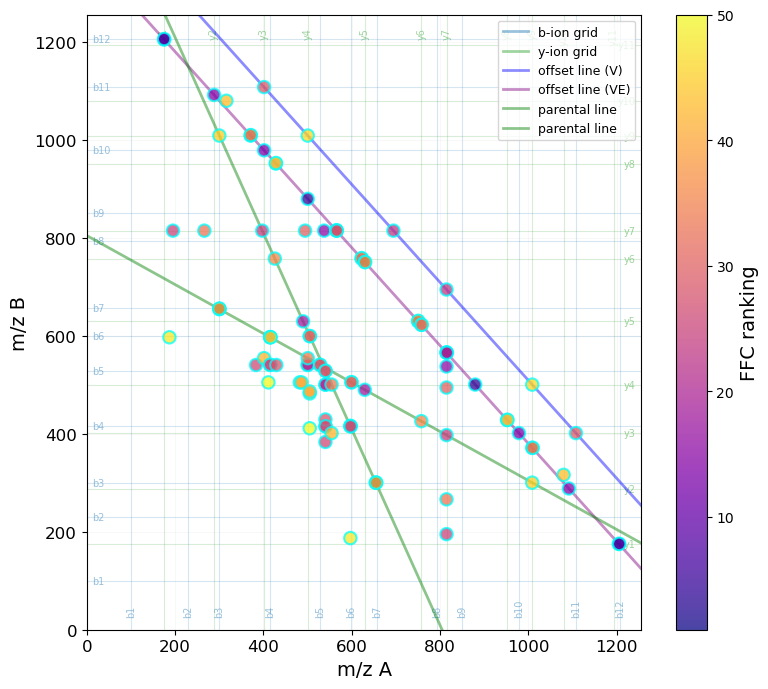

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [116]:
plot_ffc_map_by_grid_type(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_label_alpha=0.45,
    grid_label_fontsize=7
)

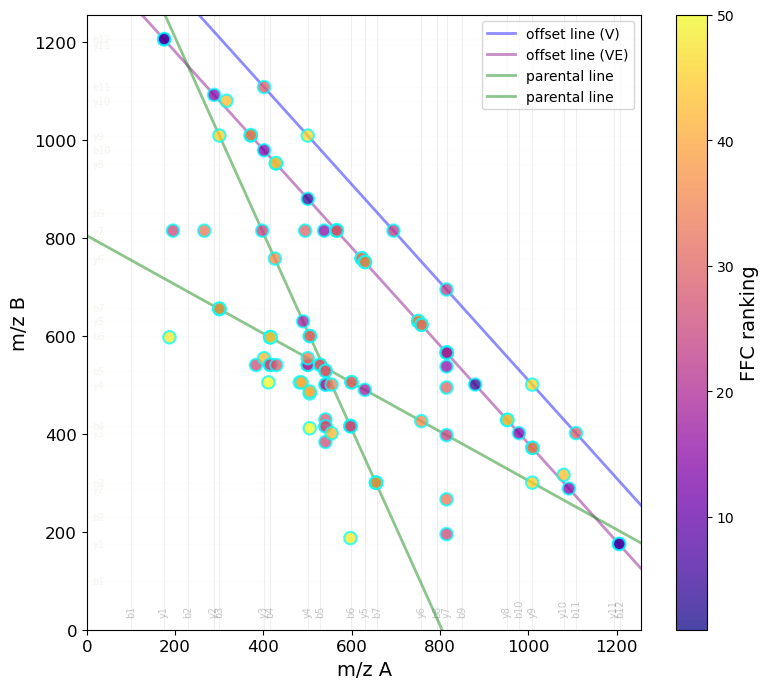

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [113]:
plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=combined_ions,
    y_ions=combined_ions,
    start_from_zero=True,
    grid_alpha=0.12,
    grid_label_alpha=0.45,
    grid_label_fontsize=7
)

In [51]:
b_ions

{'b1': 100.07566,
 'b2': 229.11825,
 'b3': 300.15536,
 'b4': 415.18229999999994,
 'b5': 528.26636,
 'b6': 599.30347,
 'b7': 656.32493,
 'b8': 793.38384,
 'b9': 850.4053,
 'b10': 978.46388,
 'b11': 1107.50647,
 'b12': 1206.5748800000001,
 'b13': 1319.65894,
 'b14': 1432.743}

In [62]:
mms_df.head()

,m/z A,m/z B,Ranking,annotation A,annotation B
346,175.119605,1204.639002,1,y1 (+1),internal 3:14 (+1)
347,175.119605,1205.641873,8,y1 (+1),internal 3:14 (+1) (C13)
613,187.072039,596.845575,48,internal 3:4 (+1),y11 (+2)
856,195.088350,814.482029,25,internal 7:8 (+1) / internal 8:9 (+1),y7 (+1)
2248,266.125697,814.482029,33,internal 6:8 (+1) / internal 3:8-H2O-NH3 (+2) ...,y7 (+1)


In [ ]:
#mms_df.to_csv('point_not_line_VEA.csv')

In [75]:
ranking_to_drop = [3, 9, 12, 10, 24, 36, 18, 34, 61, 7, 19, 2, 11, 5, 4, 13, 14, 1, 46, 23, 29] 
df_filtered = mms_df[~mms_df["Ranking"].isin(ranking_to_drop)].copy()

In [76]:
df_filtered.head()

,m/z A,m/z B,Ranking,annotation A,annotation B
347,175.119605,1205.641873,8,y1 (+1),internal 3:14 (+1) (C13)
613,187.072039,596.845575,48,internal 3:4 (+1),y11 (+2)
856,195.088350,814.482029,25,internal 7:8 (+1) / internal 8:9 (+1),y7 (+1)
2248,266.125697,814.482029,33,internal 6:8 (+1) / internal 3:8-H2O-NH3 (+2) ...,y7 (+1)
2892,300.156407,654.860832,6,b3 (+1) / b6 (+2) / internal 3:5 (+1) / intern...,y12 (+2) (C13)


In [ ]:
#df_filtered.to_csv('point_not_line_VEA.csv')

In [95]:
df_annot = pd.read_csv('point_not_line_VEA.csv')
df_annot.head()

,Unnamed: 0,m/z A,m/z B,Ranking,annotation A,annotation B
0,347,175.119605,1205.641873,8,y1 (+1),internal 3:14 (+1) (C13)
1,613,187.072039,596.845575,48,internal 3:4 (+1),y11 (+2)
2,856,195.088350,814.482029,25,internal 7:8 (+1),y7 (+1)
3,2248,266.125697,814.482029,33,internal 6:8 (+1),y7 (+1)
4,2892,300.156407,654.860832,6,b3 (+1),y12 (+2) (C13)


In [103]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_annotation_map_with_table(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    make_plot_square=True,
    figsize=(18, 10),
    width_ratios=(1.25, 0.05, 1.0),
    point_size=75,
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=1.3,
    cmap="plasma",
    grid_alpha=0.08,
    grid_linewidth=0.7,
    grid_label_alpha=0.25,
    grid_label_fontsize=6,
    show_grid_labels=True,
    number_fontsize=6,
    number_alpha=0.9,
    number_dx=4,
    number_dy=4,
    table_fontsize=7.5,
    table_scale_y=1.18,
    table_col_widths=(0.48, 0.48),
    max_table_rows=None,
    sort_by_ranking=True,
    save_path=None,
):
    """
    Plot an FFC map where each point is labeled by a number.
    The side table lists the mz_A and mz_B annotations.

    The row number of the table corresponds to the point number on the plot.
    """

    data = df.copy()

    required_cols = [
        mz_a_col,
        mz_b_col,
        ranking_col,
        mz_a_anno_col,
        mz_b_anno_col,
    ]

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Convert numeric columns
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Clean annotation columns
    data[mz_a_anno_col] = data[mz_a_anno_col].fillna("").astype(str)
    data[mz_b_anno_col] = data[mz_b_anno_col].fillna("").astype(str)

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Sort and assign point numbers
    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    data["annotation_no"] = range(1, len(data) + 1)

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (
                data[mz_a_col].min() - 50,
                data[mz_a_col].max() + 50,
            )

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (
                data[mz_b_col].min() - 50,
                data[mz_b_col].max() + 50,
            )

    # Force the same x/y range for a square data-scale plot
    if make_plot_square:
        max_limit = max(xlim[1], ylim[1])
        xlim = (xlim[0], max_limit)
        ylim = (ylim[0], max_limit)

    # ------------------------------------------------------------
    # Create custom layout:
    # plot | colorbar | table
    # ------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=width_ratios,
        wspace=0.18,
    )

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_table = fig.add_subplot(gs[0, 2])

    # ------------------------------------------------------------
    # Faint b/y ion grid
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.015 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.008 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = fig.colorbar(scatter, cax=cax)
    cbar.set_label("FFC ranking", fontsize=13)

    # ------------------------------------------------------------
    # Number labels on points
    # ------------------------------------------------------------

    for _, row in data.iterrows():
        ax.annotate(
            str(int(row["annotation_no"])),
            xy=(row[mz_a_col], row[mz_b_col]),
            xytext=(number_dx, number_dy),
            textcoords="offset points",
            fontsize=number_fontsize,
            alpha=number_alpha,
            ha="left",
            va="bottom",
            zorder=4,
            clip_on=True,
        )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if make_plot_square:
        ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.18, linewidth=0.5)

    # ------------------------------------------------------------
    # Side annotation table
    # ------------------------------------------------------------

    ax_table.axis("off")

    table_data = data.copy()

    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []

    for _, row in table_data.iterrows():
        table_rows.append([
            row[mz_a_anno_col],
            row[mz_b_anno_col],
        ])

    col_labels = ["m/z A annotation", "m/z B annotation"]

    table = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        rowLabels=[str(i) for i in table_data["annotation_no"]],
        cellLoc="left",
        colLoc="left",
        rowLoc="center",
        loc="center",
        colWidths=table_col_widths,
        bbox=[0, 0, 1, 1],   # fill the table panel
    )

    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    # Style table
    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.35)

        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")

    # Improve spacing around the whole figure
    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        bottom=0.08,
        top=0.97,
        wspace=0.18,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data

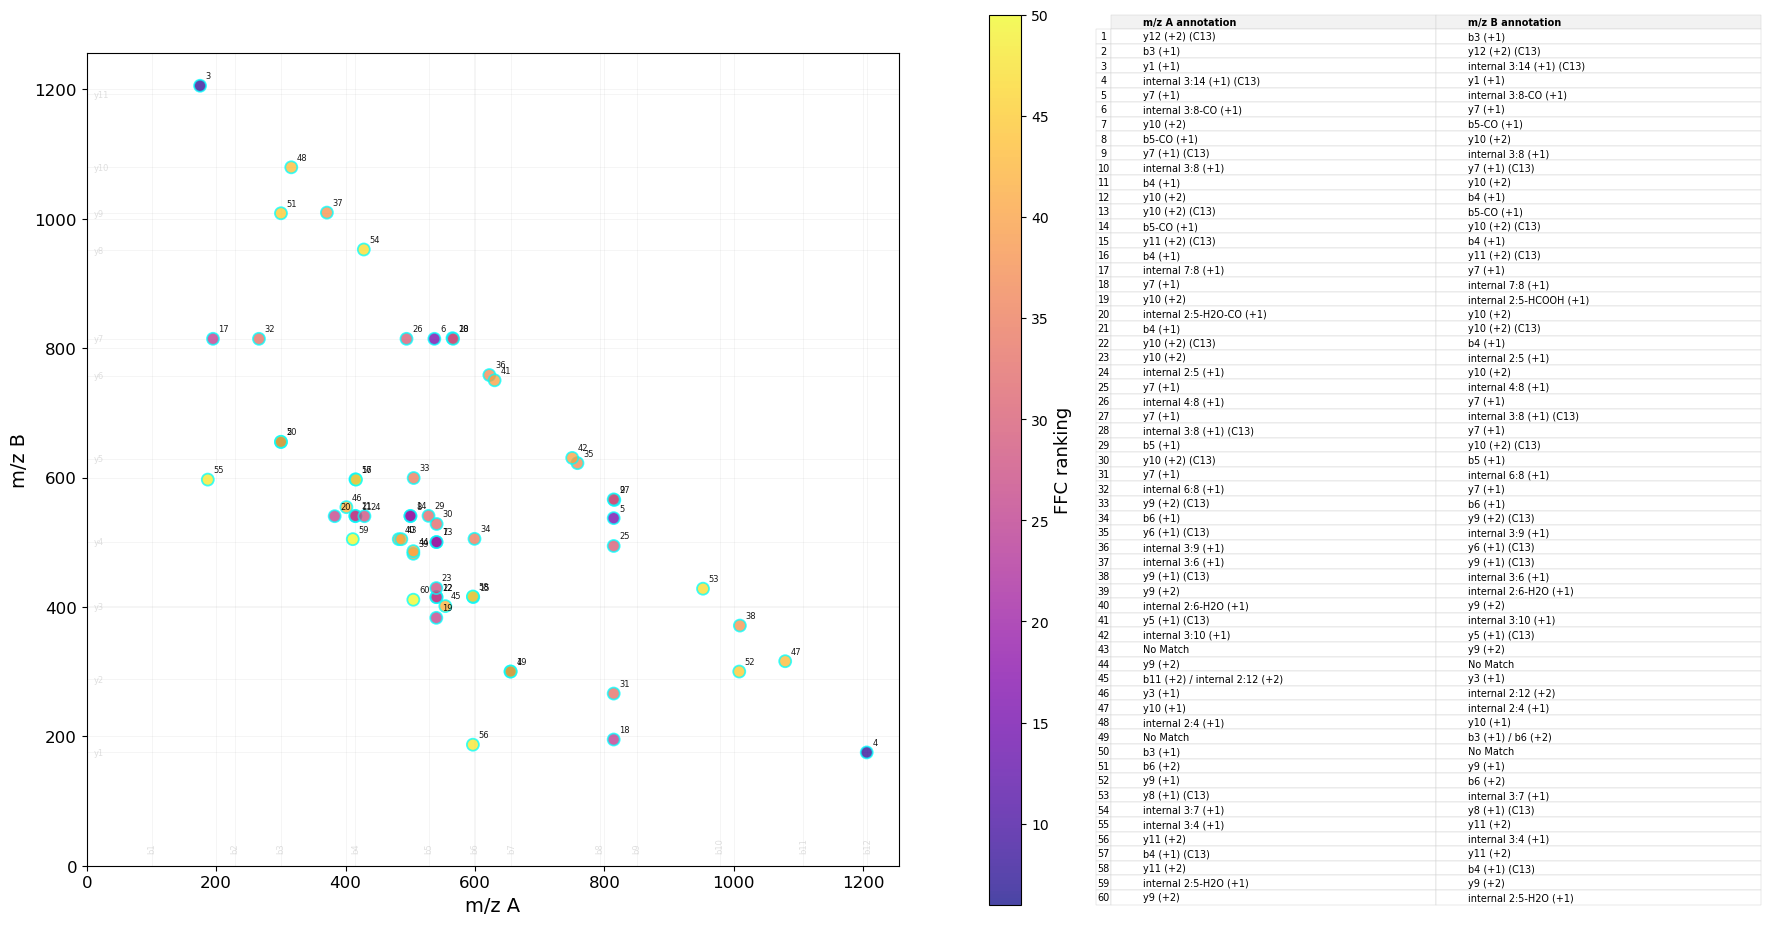

In [104]:
fig, ax, ax_table, annotated_df = plot_ffc_annotation_map_with_table(
    df_annot,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    sort_by_ranking=True,
    table_fontsize=7,
)